# How to create a simple Sequential NN using pytorch

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

## 🧱 Step 1. Create a simple dataset

- Let’s start with a toy regression example:
- Predict y = 3x + 2 with some noise.

In [4]:
# Generate data
x = torch.linspace(-5, 5, 100).unsqueeze(1)   # shape [100, 1]
y = 3 * x + 2 + torch.randn(x.size()) * 0.5   # noisy linear relation

## 🧠 Step 2. Define a neural network

- Let’s build a 2-layer fully connected NN.
### 💡 Explanation:
- nn.Linear(in, out) creates a layer that does y = xW + b
- nn.ReLU() introduces non-linearity
- forward() defines how data flows through the network

In [5]:
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 16),   # input → hidden
            nn.ReLU(),          # activation
            nn.Linear(16, 1)    # hidden → output
        )
        
    def forward(self, x):
        return self.net(x)

## ⚙️ Step 3. Instantiate the model, loss, and optimizer
- criterion defines how we measure error.
- optimizer updates model weights using gradients (here SGD).

In [6]:
model = SimpleNN()
criterion = nn.MSELoss()          # Mean Squared Error for regression
optimizer = optim.SGD(model.parameters(), lr=0.01)

## 🔁 Step 4. Training loop
- 💡 What happens each step:
1.	preds = model(x) → forward pass
2.	loss.backward() → PyTorch computes gradients for all parameters
3.	optimizer.step() → parameters updated based on gradients


In [7]:
for epoch in range(500):
    optimizer.zero_grad()          # reset gradients
    preds = model(x)               # forward pass
    loss = criterion(preds, y)     # compute loss
    loss.backward()                # compute gradients
    optimizer.step()               # update weights

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 76.4753
Epoch 50, Loss: 0.2704
Epoch 100, Loss: 0.2288
Epoch 150, Loss: 0.2196
Epoch 200, Loss: 0.2156
Epoch 250, Loss: 0.2132
Epoch 300, Loss: 0.2117
Epoch 350, Loss: 0.2105
Epoch 400, Loss: 0.2096
Epoch 450, Loss: 0.2089


## 📈 Step 5. Test and visualize

In [8]:
with torch.no_grad():  # no gradients needed
    test_x = torch.linspace(-5, 5, 100).unsqueeze(1)
    preds = model(test_x)

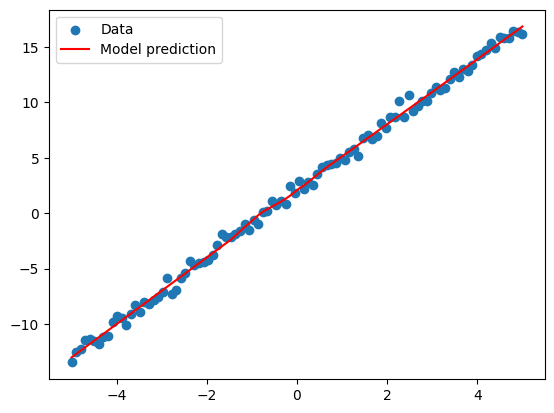

In [9]:
import matplotlib.pyplot as plt

plt.scatter(x, y, label='Data')
plt.plot(test_x, preds, color='red', label='Model prediction')
plt.legend()
plt.show()

# -------------------------------------------------- Linear Algebra of NN --------------------------------------------------------------------

In [10]:
import torch
x = torch.tensor([[1.0, 2.0]])       # input (1x2)
W = torch.tensor([[0.5], [0.2]], requires_grad=True)
b = torch.tensor([0.1], requires_grad=True)

y_pred = x @ W + b
loss = (y_pred - torch.tensor([[1.0]])) ** 2
loss.backward()

print("y_pred:", y_pred.item())
print("W.grad:", W.grad)
print("b.grad:", b.grad)

y_pred: 1.0
W.grad: tensor([[0.],
        [0.]])
b.grad: tensor([0.])


## Practice Questions
### Q1: We can do a hands-on exploration now to really internalize this:
- Create a tiny 2-layer network with tensors
- Print .grad_fn for every intermediate tensor
- Compute .backward()
- Inspect .grad for each parameter
- Try .detach() and no_grad to see how the graph is affected

In [11]:
x1 = torch.tensor(np.random.choice(range(1, 100), 3),dtype=torch.float32)
W1 = torch.tensor(np.random.choice(range(1, 10), 3),dtype=torch.float32, requires_grad=True)
b1 = torch.tensor(np.random.choice(range(1, 30), 3),dtype=torch.float32, requires_grad=True)
layer_1 = W1 @ x1 + b1
print("layer1:", layer_1)
print("layer1.grad_fn:", layer_1.grad_fn)
act_1 = torch.relu(layer_1)

W2 = torch.tensor(np.random.rand(3),dtype=torch.float32, requires_grad=True)
b2 = torch.tensor(np.random.rand(1),dtype=torch.float32, requires_grad=True)

output = W2 @ act_1 + b2
print("Output layer:", output)
print("Output Layer .grad_fn:", output.grad_fn)

loss = ((output - torch.tensor([1.0, 0.5, 2.0])) ** 2).sum()
print("loss:", loss)
print("loss.grad_fn:", loss.grad_fn)
loss.backward()

print("Gradients:")
print("dL/dW1:", W1.grad)
print("dL/db1:", b1.grad)
print("dL/dW2:", W2.grad)
print("dL/db2:", b2.grad)



layer1: tensor([203., 188., 193.], grad_fn=<AddBackward0>)
layer1.grad_fn: <AddBackward0 object at 0x1165f0970>
Output layer: tensor([324.5861], grad_fn=<AddBackward0>)
Output Layer .grad_fn: <AddBackward0 object at 0x1165f0970>
loss: tensor(313801.5312, grad_fn=<SumBackward0>)
loss.grad_fn: <SumBackward0 object at 0x1165f0970>
Gradients:
dL/dW1: tensor([35632.7422, 51829.4453,  6478.6807])
dL/db1: tensor([1020.9941, 1287.0176,  931.3286])
dL/dW2: tensor([393924.8750, 364817.1250, 374519.7188])
dL/db2: tensor([1940.5166])


### Q2: Manual 2-layer mini-MLP that mimics nn.Linear exactly, with weights shaped like PyTorch’s nn.Linear (out_features, in_features) and explicit .T for forward pass.

We’ll include:
- Forward pass
- ReLU activation
- Output layer
- Loss (MSE)
- Backpropagation
- Inspect .grad_fn and .grad

In [12]:
# ----------------------
# Step 1: Inputs
# ----------------------
# Batch of 2 samples, 3 features each
x = torch.tensor([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0]], dtype=torch.float32)

# ----------------------
# Step 2: First Layer (Linear)
# ----------------------
# Following PyTorch convention: W shape = (out_features, in_features)
W1 = torch.randn((4, 3), dtype=torch.float32, requires_grad=True)  # 4 hidden neurons
b1 = torch.randn((1, 4), dtype=torch.float32, requires_grad=True)  # broadcasted

# Forward pass: linear
z1 = x @ W1.T + b1  # shape: (batch_size, hidden_dim)
print("Layer 1 output z1:\n", z1)
print("z1.grad_fn:", z1.grad_fn)

# Activation
a1 = torch.relu(z1)
print("After ReLU a1:\n", a1)
print("a1.grad_fn:", a1.grad_fn)

# ----------------------
# Step 3: Second Layer (Output)
# ----------------------
# Output neurons = 2
W2 = torch.randn((2, 4), dtype=torch.float32, requires_grad=True)  # out_features x in_features
b2 = torch.randn((1, 2), dtype=torch.float32, requires_grad=True)

# Forward pass
z2 = a1 @ W2.T + b2  # shape: (batch_size, out_features)
print("Output layer z2:\n", z2)
print("z2.grad_fn:", z2.grad_fn)

# ----------------------
# Step 4: Loss
# ----------------------
y_true = torch.tensor([[0.5, 1.0],
                       [1.5, 2.0]], dtype=torch.float32)

loss = ((z2 - y_true)**2).mean()
print("Loss:", loss)
print("loss.grad_fn:", loss.grad_fn)

# ----------------------
# Step 5: Backprop
# ----------------------
loss.backward()

# Inspect gradients
print("Gradients:")
print("W1.grad:\n", W1.grad)
print("b1.grad:\n", b1.grad)
print("W2.grad:\n", W2.grad)
print("b2.grad:\n", b2.grad)

Layer 1 output z1:
 tensor([[-1.2855, -0.3176, -0.7593,  6.6340],
        [-2.8235,  2.5181, -2.7813, 17.8316]], grad_fn=<AddBackward0>)
z1.grad_fn: <AddBackward0 object at 0x11671df00>
After ReLU a1:
 tensor([[ 0.0000,  0.0000,  0.0000,  6.6340],
        [ 0.0000,  2.5181,  0.0000, 17.8316]], grad_fn=<ReluBackward0>)
a1.grad_fn: <ReluBackward0 object at 0x11430f5b0>
Output layer z2:
 tensor([[ 4.3102,  8.4283],
        [ 5.0679, 18.4827]], grad_fn=<AddBackward0>)
z2.grad_fn: <AddBackward0 object at 0x11430f5b0>
Loss: tensor(88.5266, grad_fn=<MeanBackward0>)
loss.grad_fn: <MeanBackward0 object at 0x11430f5b0>
Gradients:
W1.grad:
 tensor([[  0.0000,   0.0000,   0.0000],
        [-41.1023, -51.3779, -61.6535],
        [  0.0000,   0.0000,   0.0000],
        [ 44.4134,  59.3325,  74.2515]])
b1.grad:
 tensor([[  0.0000, -10.2756,   0.0000,  14.9190]])
W2.grad:
 tensor([[  0.0000,   4.4923,   0.0000,  44.4494],
        [  0.0000,  20.7529,   0.0000, 171.5963]])
b2.grad:
 tensor([[ 3.6891, 1

In [13]:
W1

tensor([[ 0.6857, -0.5993, -0.5991],
        [ 0.9674,  1.0380, -1.0601],
        [ 0.3280, -0.8842, -0.1178],
        [ 1.1152,  1.8844,  0.7330]], requires_grad=True)

In [14]:
x

tensor([[1., 2., 3.],
        [4., 5., 6.]])

## NN with Pytorch

#### Simple one layer NN with one neuron (see output dims is 1)

In [15]:
class MyNN(nn.Module):

    def __init__(self, input_dims, output_dims):
        super().__init__()
        self.my_lin_mod = nn.Linear(input_dims, output_dims)
    
    def forward(self, input_x):
        return self.my_lin_mod(input_x)

In [16]:
model = MyNN(2,1)
for name, param in model.named_parameters():
    print(f"Name: {name}\tParam:{param}")

Name: my_lin_mod.weight	Param:Parameter containing:
tensor([[0.2828, 0.6149]], requires_grad=True)
Name: my_lin_mod.bias	Param:Parameter containing:
tensor([0.0410], requires_grad=True)


In [17]:
x = torch.randn(4,2)
output = model(x)
print(f"Outout: {output}")

Outout: tensor([[ 0.7097],
        [-0.0729],
        [ 0.4169],
        [ 0.3070]], grad_fn=<AddmmBackward0>)


#### Simple NN with activation layer

In [18]:
class NNwithActivation(nn.Module):

    def __init__(self, input_dims,hidden_dims, output_dims):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dims, hidden_dims),
            nn.ReLU(),
            nn.Linear(hidden_dims, output_dims)
        )
    def forward(self, input_x):
        return self.model(input_x)
    
model = NNwithActivation(2, 3, 1)
input = torch.randn(4, 2)
output = model(input)
print(output)

tensor([[0.4488],
        [0.5177],
        [0.5234],
        [0.5810]], grad_fn=<AddmmBackward0>)


In [19]:
print(list(model.named_parameters()))

[('model.0.weight', Parameter containing:
tensor([[ 0.6100,  0.2980],
        [ 0.4120, -0.1882],
        [ 0.5832, -0.4256]], requires_grad=True)), ('model.0.bias', Parameter containing:
tensor([ 0.4870,  0.6970, -0.1181], requires_grad=True)), ('model.2.weight', Parameter containing:
tensor([[ 0.0545,  0.2369, -0.3046]], requires_grad=True)), ('model.2.bias', Parameter containing:
tensor([0.3638], requires_grad=True))]


### Activation Functions
#### 🔸 ReLU & LeakyReLU

##### ReLU (Rectified Linear Unit) 
$$ f(x) = max(0, x) ----> [0, ∞)$$
 - Most common for hidden layers; fast, avoids vanishing gradients
 - nn.ReLU()

##### Leaky ReLU
$$ 
 f(x) = max(0.01x, x) ---> (-∞, ∞)
$$
- Like ReLU but small negative slope prevents “dying” neurons
- nn.LeakyReLU(0.01)







In [ ]:
relu = nn.ReLU()
leaky = nn.LeakyReLU(0.01)
x = torch.tensor([[-2.0, -0.5, 0.5, 3.0]])
print("ReLU:", relu(x))
print("LeakyReLU:", leaky(x)) 

ReLU: tensor([[0.0000, 0.0000, 0.5000, 3.0000]])
LeakyReLU: tensor([[-0.0200, -0.0050,  0.5000,  3.0000]])


#### 🔸 Sigmoid & Tanh

##### Sigmoid
$$ f(x) = \frac{1}{1 + e^{-x}} ----> (0, 1) $$
-  Binary classification output; squashes values to probability
- nn.Sigmoid()
-  The sum of probabilities might be greater thean 1 coz the probability pertains to independent classes
##### Tanh
$$ f(x) = \tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}} ----> (-1, 1) $$
- Centered at 0; good for intermediate layers when outputs can be neg/pos
- nn.Tanh()


In [ ]:
sig = nn.Sigmoid() 
tanh = nn.Tanh()
print("Sigmoid:", sig(x))
print("Tanh:", tanh(x))

Sigmoid: tensor([[0.1192, 0.3775, 0.6225, 0.9526]])
Tanh: tensor([[-0.9640, -0.4621,  0.4621,  0.9951]])


#### 🔸 Softmax
$$f(x_i) = \frac{e^{x_i}}{\sum_j e^{x_j}}  ----> (0, 1), sum = 1 $$
- Multi-class classification output layer (probability distribution)
- The probabilties are of classes that are not independent but mutually exclusive.
- nn.Softmax(dim=1)


In [22]:
softmax = nn.Softmax(dim=1)
print("Softmax:", softmax(x))
print("Sum across classes:", softmax(x).sum(dim=1))  # should be 1

Softmax: tensor([[0.0060, 0.0270, 0.0734, 0.8936]])
Sum across classes: tensor([1.])


| Case | Type of Classes | Activation | Why |
|------|----------------|-----------|-----|
| Mutually Exclusive Classes | Only one can be true at a time (e.g., cat or dog or horse) | Softmax | Ensures probabilities sum to 1; encourages “competition” between outputs |
| Independent Classes | Multiple can be true at once (e.g., image has a cat and a dog) | Sigmoid | Treats each output as an independent yes/no probability |

### Loss Functions

#### 1️⃣ Why Loss Functions
- Loss functions quantify how wrong the model predictions are compared to the true labels.
- Backpropagation computes gradients of the loss w.r.t. every parameter to guide weight updates.
#### 2️⃣ Common Losses
| Task | Output Activation | PyTorch Loss | Notes |
|------|-----------------|--------------|-------|
| Regression | Linear (no activation) | nn.MSELoss() | Mean Squared Error; continuous outputs |
| Binary Classification | Sigmoid | nn.BCEWithLogitsLoss() | Combines sigmoid + BCE in a numerically stable way |
| Multi-class Classification | Softmax | nn.CrossEntropyLoss() | Expects raw logits; softmax applied internally |
| Multi-label Classification | Sigmoid | nn.BCEWithLogitsLoss() | Independent yes/no outputs per label |

3️⃣ Key Points
1.	MSELoss:
$$\text{loss} = \frac{1}{N}\sum_i (\hat{y}_i - y_i)^2$$
2.	Binary Cross-Entropy:
$$\text{loss} = -\frac{1}{N} \sum_i \left[ y_i \log(\hat{y}_i) + (1 - y_i)\log(1 - \hat{y}_i) \right]$$
- Sigmoid applied inside BCEWithLogitsLoss → numerical stability
3.	Cross-Entropy (multi-class):
- Takes raw logits
- Softmax + log likelihood applied internally
- Output: scalar loss across batch


In [23]:
# Regression
y_true = torch.tensor([[2.0], [0.5]])
y_pred = torch.tensor([[1.8], [0.4]])
mse = nn.MSELoss()
print("MSE:", mse(y_pred, y_true).item())

# Binary Classification (sigmoid output)
y_true_bin = torch.tensor([[1.0], [0.0]])
logits = torch.tensor([[0.8], [-1.2]])  # raw outputs
bce = nn.BCEWithLogitsLoss()
print("BCEWithLogits:", bce(logits, y_true_bin).item())

# Multi-class Classification (softmax inside CrossEntropyLoss)
y_true_class = torch.tensor([2, 0])  # class indices
logits_multi = torch.tensor([[1.0, 2.0, 3.0],
                             [2.0, 1.0, 0.1]])  # raw logits
ce = nn.CrossEntropyLoss()
print("CrossEntropy:", ce(logits_multi, y_true_class).item())

MSE: 0.025000007823109627
BCEWithLogits: 0.31719154119491577
CrossEntropy: 0.4123179316520691


#### Optimizers

1️⃣ Why Optimizers
- Backprop gives us gradients of loss w.r.t. each parameter.
- Optimizers define how to update the parameters using those gradients.
- Key idea: move weights in the direction that minimizes the loss.

2️⃣ Common Optimizers in PyTorch

| Optimizer | Formula / Update Rule | Notes |
|-----------|----------------------|-------|
| SGD | \( \theta \leftarrow \theta - \eta \nabla_\theta L \) | Vanilla gradient descent; learning rate \(\eta\) controls step size |
| SGD + Momentum | \( v = \gamma v + \eta \nabla_\theta L, \quad \theta \leftarrow \theta - v \) | Momentum smooths updates; \(\gamma \approx 0.9\) |
| Adam | Adaptive LR using running estimates of first & second moments | Widely used; generally fast convergence |
| RMSprop | Adaptive learning rate dividing by sqrt of avg squared gradients | Good for non-stationary problems |

4️⃣ Key Points to Remember

1.	Zero gradients each step: optimizer.zero_grad() prevents accumulation from previous batches.
2.	Step updates weights: optimizer.step() applies the gradient descent update.
3.	Learning rate matters: too high → divergence, too low → slow convergence.
4.	Momentum/Adam help smooth updates and adapt learning rates per parameter.

In [26]:
model = nn.Sequential(nn.Linear(2,3), nn.ReLU(), nn.Linear(3,1))
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
loss_fn = nn.MSELoss()

# Dummy data
x = torch.randn(5,2)
y = torch.randn(5,1)

# Forward pass
y_pred = model(x)
loss = loss_fn(y_pred, y)

# Backward pass
optimizer.zero_grad()   # reset gradients
loss.backward()         # compute gradients
optimizer.step()        # update weights

print(list(model.named_parameters()))

[('0.weight', Parameter containing:
tensor([[ 0.6898,  0.3240],
        [ 0.2403, -0.2691],
        [ 0.4686, -0.4359]], requires_grad=True)), ('0.bias', Parameter containing:
tensor([-0.1607,  0.0101,  0.5816], requires_grad=True)), ('2.weight', Parameter containing:
tensor([[-0.3549, -0.4802,  0.5148]], requires_grad=True)), ('2.bias', Parameter containing:
tensor([0.0095], requires_grad=True))]


#### Batch Training Loop
1️⃣ Why Batch Training
- Neural networks are typically trained on mini-batches, not single samples, for efficiency and stable gradients.
- Each iteration:
	1.	Forward pass: compute predictions
	2.	Compute loss
	3.	Backward pass: compute gradients
	4.	Optimizer step: update weights

2️⃣ Key Notes for Interviews
1.	Zero gradients each batch: optimizer.zero_grad()
2.	Forward → loss → backward → step is the standard sequence
3.	Mini-batches:
- Larger batch → smoother gradients, slower updates
- Smaller batch → noisier gradients, potentially better generalization
4.	Learning rate is critical: too high → divergence; too low → slow convergence

5.	Can combine with:
- Momentum or Adam
- Learning rate schedules
- Regularization like dropout



In [40]:
class TwoLayerNN(nn.Module):

    def __init__(self, input_dims, hidden_dims, output_dims):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dims, hidden_dims),
            nn.ReLU(),
            nn.Linear(hidden_dims, output_dims)
        )
    def forward(self, input_x):
        return self.model(input_x)
    
epochs = 100
model = TwoLayerNN(2, 3, 1)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


X = torch.randn(1000, 2)
y = torch.rand(1000, 1)
len_x = len(X)

batch_size = 50
for epoch in range(epochs):
    model.train()
    for i in range(0, len_x, batch_size):
        optimizer.zero_grad()
        X_batch = X[i: i + batch_size]
        y_batch = y[i: i + batch_size]
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()
    model.eval()
    with torch.no_grad():
        y_val_pred = model(X)
    if epoch % 10 == 0:
        print(f"pred on train set:\t pre:{y_val_pred[0]}\t Actual: {y[0]}")
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}") 


pred on train set:	 pre:tensor([0.6443])	 Actual: tensor([0.0795])
Epoch 1, Loss: 0.1983
pred on train set:	 pre:tensor([0.7089])	 Actual: tensor([0.0795])
Epoch 11, Loss: 0.1143
pred on train set:	 pre:tensor([0.6265])	 Actual: tensor([0.0795])
Epoch 21, Loss: 0.1105
pred on train set:	 pre:tensor([0.5893])	 Actual: tensor([0.0795])
Epoch 31, Loss: 0.1100
pred on train set:	 pre:tensor([0.5684])	 Actual: tensor([0.0795])
Epoch 41, Loss: 0.1092
pred on train set:	 pre:tensor([0.5454])	 Actual: tensor([0.0795])
Epoch 51, Loss: 0.1094
pred on train set:	 pre:tensor([0.5265])	 Actual: tensor([0.0795])
Epoch 61, Loss: 0.1102
pred on train set:	 pre:tensor([0.5171])	 Actual: tensor([0.0795])
Epoch 71, Loss: 0.1106
pred on train set:	 pre:tensor([0.5140])	 Actual: tensor([0.0795])
Epoch 81, Loss: 0.1107
pred on train set:	 pre:tensor([0.5131])	 Actual: tensor([0.0795])
Epoch 91, Loss: 0.1107
